# Cours 2 : Algorithmes non supervisés 

## Préambule

Les objectifs de cette séance (3h) sont :
* Mettre en application un modèle non-supervisé (K-means et C.A.H)

## Préparation du workspace

### Import de librairies 

In [ ]:
# Données
import numpy as np
import pandas as pd

# Graphiques
import seaborn as sns

sns.set()
import matplotlib.pyplot as plt  # noqa: E402
from scipy.cluster.hierarchy import dendrogram, linkage  # noqa: E402

# Statistiques
from scipy.stats import chi2_contingency  # noqa: E402, F401

# Machine Learning
from sklearn.cluster import AgglomerativeClustering, KMeans  # noqa: E402


### Constantes

In [2]:
input_path = "./1_inputs"
output_path = "./2_outputs"

## Exercice (implémentation des exercices du support de cours)

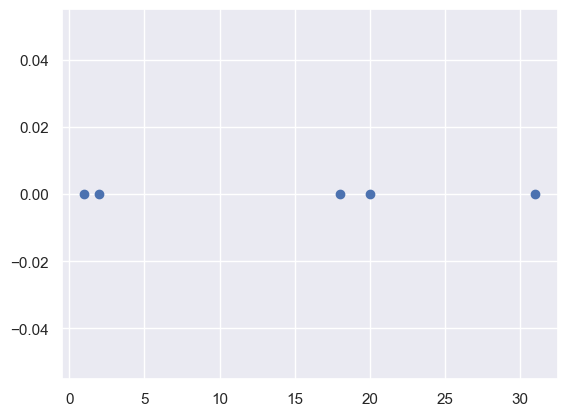

In [3]:
#Défintion de E
x = [1, 2, 18, 20, 31]

#Représentation graphique
y=[0, 0, 0, 0, 0]
plt.scatter(x, y)
plt.show()

### K-means : Question 1 

**Déterminer la partition optimale par k-means en prenant pour centres initiaux les éléments 1, 2, 18**

In [4]:
#Définition des centres initiaux
init_points = np.array([1, 2, 18])

#Itinitialisation algo
kmeans = KMeans(init=init_points.reshape(-1,1),
                n_clusters=3,
                n_init = 1)

In [5]:
#Transformation des données : plusieurs échantillons de 1 dimension
data_x = np.array(x)
data_x = data_x.reshape(-1,1)

# Fitting
kmeans.fit(data_x)

KMeans(init=array([[ 1],
       [ 2],
       [18]]), n_clusters=3, n_init=1)

In [6]:
#Centroides finaux
final_centroids =  kmeans.cluster_centers_
labels = kmeans.labels_

final_centroids

array([[ 1.],
       [ 2.],
       [23.]])

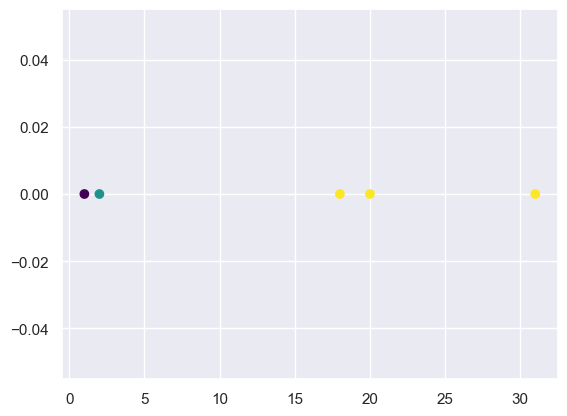

In [7]:
#Représentation Graphique
plt.scatter(x, y, c=labels, cmap='viridis')
plt.show()

### K-means : Question 2

**Déterminer la partition optimale par k-means en prenant pour centres initiaux les éléments 18, 20, 31**

In [8]:
#Définition des centres initiaux
init_points = np.array([18, 20, 31])

#Itinitialisation algo
kmeans = KMeans(init=init_points.reshape(-1,1),
                n_clusters=3,
                n_init = 1)

#Transformation des données : plusieurs échantillons de 1 dimension
data_x = np.array(x)
data_x = data_x.reshape(-1,1)

# Fitting
kmeans.fit(data_x)

#Centroides finaux
final_centroids =  kmeans.cluster_centers_
labels = kmeans.labels_

final_centroids

array([[ 1.5],
       [19. ],
       [31. ]])

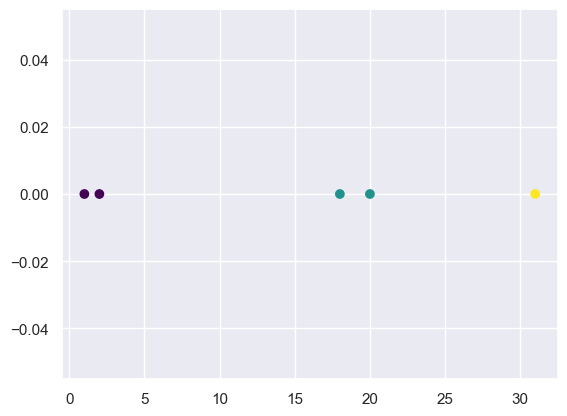

In [9]:
#Représentation Graphique
plt.scatter(x, y, c=labels, cmap='viridis') # type: ignore
plt.show()

### K-means : Question 3

**Déterminer la partition optimale par k-means en prenant comme partition initiale {{1},{2,18},{20,31}}**

In [10]:
#Définition des centres initiaux
init_points = np.array([1, np.mean([2, 18]), np.mean([20, 31])])

#Itinitialisation algo
kmeans = KMeans(init=init_points.reshape(-1,1),
                n_clusters=3,
                n_init=1)

#Transformation des données : plusieurs échantillons de 1 dimension
data_x = np.array(x)
data_x = data_x.reshape(-1,1)

# Fitting
kmeans.fit(data_x)

#Centroides finaux
final_centroids =  kmeans.cluster_centers_
labels = kmeans.labels_

final_centroids

array([[ 1.5],
       [19. ],
       [31. ]])

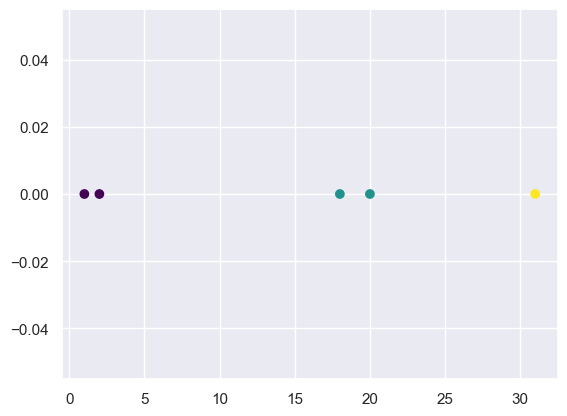

In [11]:
#Représentation Graphique
plt.scatter(x, y, c=labels, cmap='viridis')
plt.show()

### Classification Ascendante Hiérarchique avec le lien simple

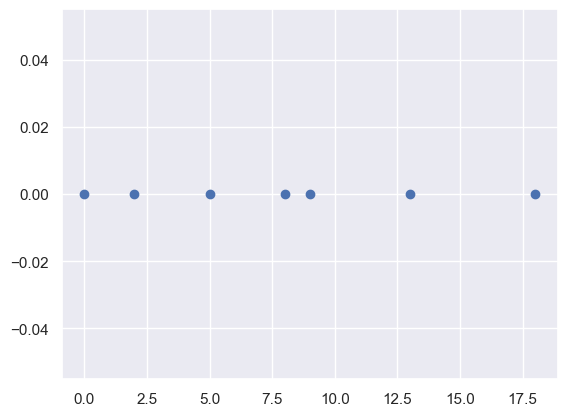

In [12]:
#Défintion de E
x = [0, 2, 5, 8, 9, 13, 18]

#Représentation graphique
y=[0, 0, 0, 0, 0, 0, 0]
plt.scatter(x, y)
plt.show()

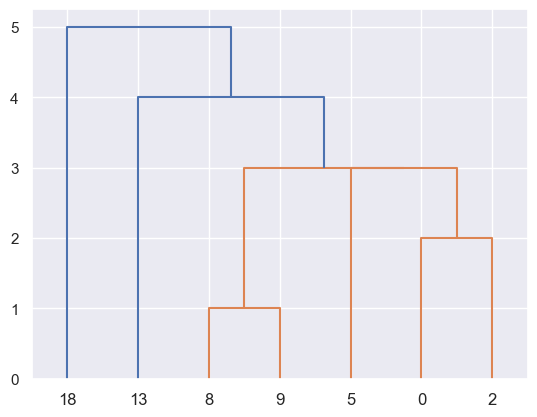

In [13]:
#Calcul de CAH avec lien simple
data = list(zip(x, strict=False))

linkage_data = linkage(data, method='single', metric='euclidean')
dendrogram(linkage_data, labels=x)

plt.show()

[0 0 0 0 0 2 1]


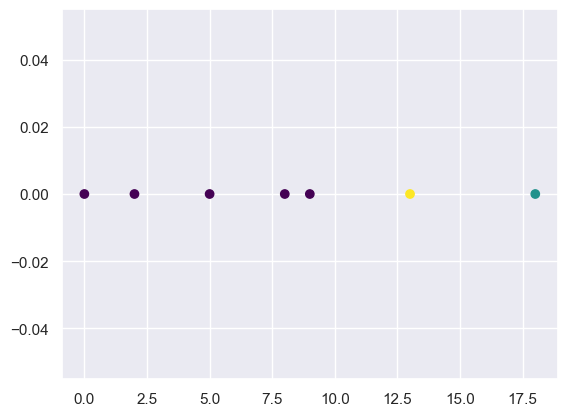

In [14]:
#Calcul de la partition de l'espace
hierarchical_cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='single')

labels = hierarchical_cluster.fit_predict(data) # type: ignore
print(labels)

#Représentation Graphique
plt.scatter(x, y, c=labels, cmap='viridis')
plt.show()

### Classification Ascendante Hiérarchique avec le lien complet

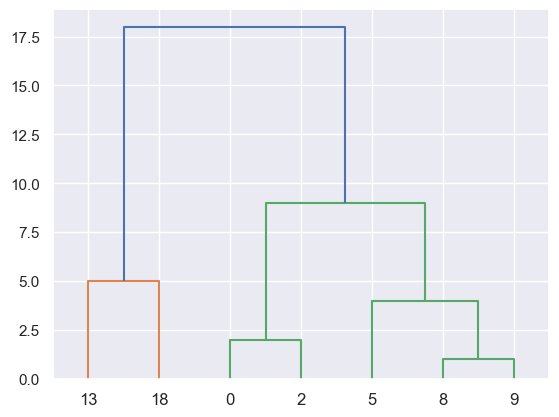

In [15]:
#Calcul de CAH avec lien complet
data = list(zip(x, strict=False))

linkage_data = linkage(data, method='complete', metric='euclidean')
dendrogram(linkage_data, labels=x)

plt.show()

[2 2 1 1 1 0 0]


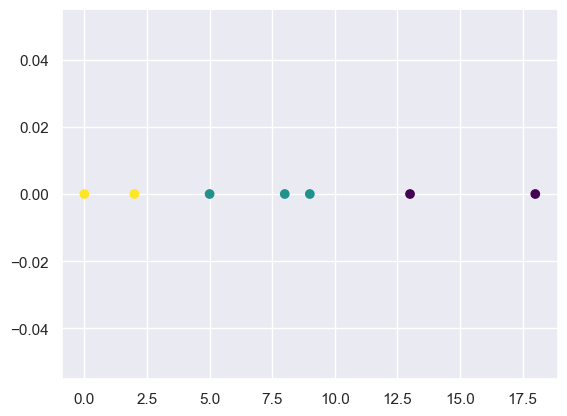

In [16]:
#Calcul de la partition de l'espace
hierarchical_cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete')

labels = hierarchical_cluster.fit_predict(data) # type: ignore
print(labels)

#Représentation Graphique
plt.scatter(x, y, c=labels, cmap='viridis')
plt.show()

## K-means: Cas pratique

### Import des données

In [ ]:
path = input_path + '/base_retraitee.csv'
data_retraitee = pd.read_csv(path, sep=",", decimal=".")

# Group by ZONE_RISQUE and aggregate the necessary columns
data = data_retraitee.groupby(["ZONE_RISQUE"], as_index=False).agg({
    'NB': 'sum',
    'CHARGE': 'sum',
    'EXPO': 'sum'
})

# Calculate derived metrics
data["FREQ"] = data["NB"] / data["EXPO"]
data["FREQ"] = data["FREQ"].fillna(0)

data["CM"] = data["CHARGE"] / data["NB"]
data["CM"] = data["CM"].fillna(0)

data["FREQxCHARGE"] = data["FREQ"] * data["CHARGE"]
data["FREQxCHARGE"] = data["FREQxCHARGE"].fillna(0)

data

,ZONE_RISQUE,NB,CHARGE,EXPO,FREQ,CM,FREQxCHARGE
0,A,236,1174911.57,9.864309e+05,0.000239,4978.438856,281.093316
1,B,181,1146823.23,9.092434e+05,0.000199,6336.039945,228.294222
2,C,284,1926300.00,1.356655e+06,0.000209,6782.746479,403.248718
3,D,83,455800.64,3.147680e+05,0.000264,5491.573976,120.188374
4,E,20,181747.82,1.378742e+05,0.000145,9087.391000,26.364305
5,F,1,19418.42,1.212972e+04,0.000082,19418.420000,1.600897
6,G,5,29820.87,2.693550e+04,0.000186,5964.174000,5.535607
7,H,14,86476.90,4.617415e+04,0.000303,6176.921429,26.219790
8,I,4,32686.63,1.398137e+04,0.000286,8171.657500,9.351478
9,J,12,75580.99,2.869872e+04,0.000418,6298.415833,31.603219


**Exercice :** Regrouper les zones géographiques en 5 zones homogènes en termes :
* Fréquence de sinistres (La fréquence est égale au Nombre de sinistres divisé par l'exposition)
* Charge 
* Fréquence de sinistres x Charge  
  
A chaque fois :
* Afficher les coordonnées des centroïdes
* Représenter graphiquement la partition obtenue

### Regroupement de zones selon la fréquence

[[1.45059813e-04]
 [2.06105405e-05]
 [9.89338927e-04]
 [3.13499008e-04]
 [2.13297250e-04]]


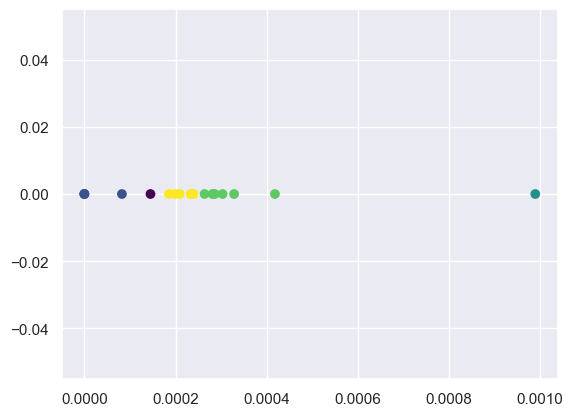

In [18]:
#Itinitialisation algo
kmeans = KMeans(init='random', n_clusters=5, n_init=1, random_state=42)

#Transformation des données : plusieurs échantillons de 1 dimension
data_x = data["FREQ"].to_numpy()
data_x = data_x.reshape(-1,1)

# Fitting
kmeans.fit(data_x)

#Centroides finaux
final_centroids =  kmeans.cluster_centers_
labels = kmeans.labels_

print(final_centroids)

#Représentation Graphique
y = np.zeros_like(data_x)
plt.scatter(data_x, y, c=labels, cmap='viridis')
plt.show()

### Regroupement de zones selon le coût moyen

[[ 5946.98129932]
 [    0.        ]
 [ 8629.52425   ]
 [ 3146.87642857]
 [19418.42      ]]


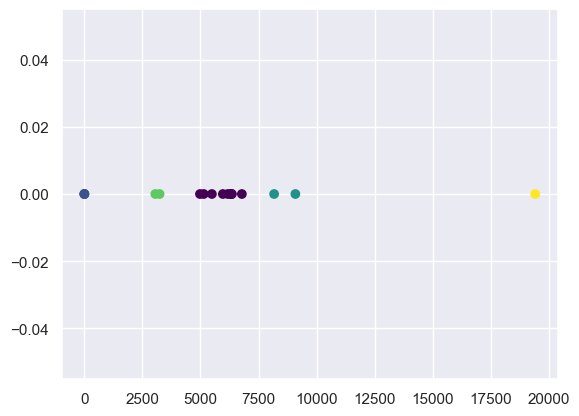

In [19]:
#Itinitialisation algo
kmeans = KMeans(init='random', n_clusters=5, n_init=1, random_state=42)

#Transformation des données : plusieurs échantillons de 1 dimension
data_x = data['CM'].to_numpy()
data_x = data_x.reshape(-1,1)

# Fitting
kmeans.fit(data_x)

#Centroides finaux
final_centroids =  kmeans.cluster_centers_
labels = kmeans.labels_

print(final_centroids)

#Représentation Graphique
y = np.zeros_like(data_x)
plt.scatter(data_x, y, c=labels, cmap='viridis')
plt.show()

### Regroupement de zones selon (fréquence; le coût moyen)

[[  6.88870225]
 [  0.52077154]
 [ 26.14306157]
 [120.18837399]
 [304.21208557]]


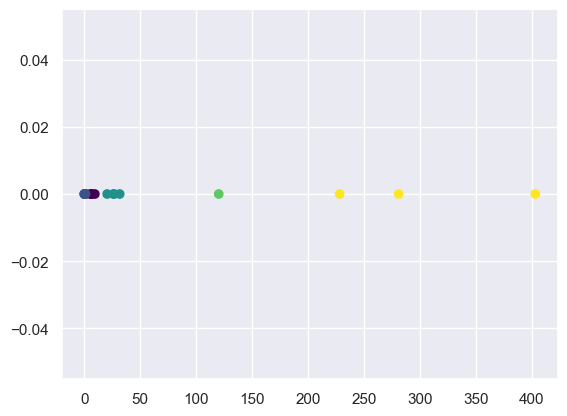

In [20]:
#Itinitialisation algo
kmeans = KMeans(init='random', n_clusters=5, n_init=1, random_state=42)

#Transformation des données : plusieurs échantillons de 1 dimension
data_x = data['FREQxCHARGE'].to_numpy()
data_x = data_x.reshape(-1,1)

# Fitting
kmeans.fit(data_x)

#Centroides finaux
final_centroids =  kmeans.cluster_centers_
labels = kmeans.labels_

print(final_centroids)

#Représentation Graphique
y = np.zeros_like(data_x)
plt.scatter(data_x, y, c=labels, cmap='viridis')
plt.show()

## C.A.H : Cas pratique

**Exercice :** Comparer les résultats obtenus via K-means à ceux d'une C.A.H (lien simple) pour la fréquence et (fréquence; coût moyen)
  
A chaque fois :
* Tracer le dendrogramme associé
* Représenter graphiquement la partition obtenue

### Regroupement de zones selon la fréquence

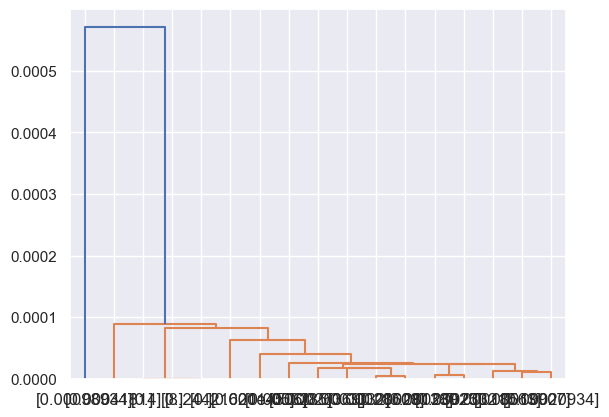

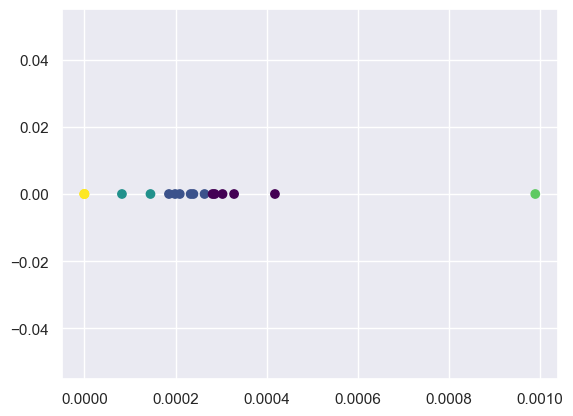

In [21]:
#Calcul de CAH avec lien simple
data_x = data['FREQ'].to_numpy()
data_x = data_x.reshape(-1,1)


linkage_data = linkage(data_x, method='single', metric='euclidean')
dendrogram(linkage_data, labels=data_x)

plt.show()

#Calcul de la partition de l'espace
hierarchical_cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='complete')

labels = hierarchical_cluster.fit_predict(data_x) # type: ignore

#Représentation Graphique
y = np.zeros_like(data_x)
plt.scatter(data_x, y, c=labels, cmap='viridis')
plt.show()

### Regroupement de zones selon (fréquence; le coût moyen)

In [22]:
#Complétez avec votre code

## Application  : création de Model Points (K-means)

Dans certains cas, il se peut que la modélisation ligne par ligne ne soit pas adaptée. C'est le cas des produits collectifs en assurance ou lorsque le nombre d'individus est trop important.  
Dans ce cas de figure, il est nécessaire d'agréger l'information afin d'avoir des "individus type". Chacun de ces individus est appelé *Model Point*.  
L'algorithme des k-means peut s'avérer utile pour le regroupement d'individus sous forme de *Mode Points* lorsque les variables explicatives sont numériques.  
  
Afin d'illustre ce propos, nous agrègerons la base de données selon les variables ANNEE_CTR, AGE_ASSURE_PRINCIPAL, ANCIENNETE_PERMIS et ANNEE_CONSTRUCTION afin de créer 100 Model Points.  

**Exercice :** Construire la nouvelle base de modélisation (les nouveaux individus deviennent les Model Points et chacune de modalités devient le centroïde de la classe).

In [23]:
#Complétez avec votre code